# N군 - 니코틴 제제

In [1]:
!pip install -q statsmodels
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='NanumGothic')

BURG = ['#5e1223','#8b1a2f','#a83248','#c25a6e','#d98a99']
burg_cmap = sns.blend_palette(['#fbe9ec','#c25a6e','#5e1223'], as_cmap=True)

# 데이터 로드 및 N계열 니코틴 제제 필터링 + 제형 분류
df = pd.read_csv('/content/FDA_adverse_events_final.csv')
n_group = df[df['WHO_ATC'] == 'N']
nic = n_group[n_group['suspect_drug'].str.contains('nicotine', case=False, na=False)].copy()

def tag_form(text):
    """제형 분류: 니코틴 분석의 핵심 비교축"""
    t = str(text).lower()
    if 'patch' in t or 'transdermal' in t or 'film' in t: return '패치/경피'
    if 'gum' in t or 'polacrilex' in t or 'lozenge' in t: return '껌/구강'
    return '기타/불명'
nic['form'] = nic['suspect_drug'].apply(tag_form)
print(f'니코틴 제제: {len(nic)}건')
print(nic['form'].value_counts())

니코틴 제제: 209건
form
껌/구강     105
기타/불명     64
패치/경피     40
Name: count, dtype: int64


In [2]:
# 연령/성별/체중 파생 변수 + 심각도 플래그 bool 변환
nic['age_num'] = pd.to_numeric(nic['patient_age_years'], errors='coerce')
nic.loc[(nic['age_num'] <= 0) | (nic['age_num'] > 120), 'age_num'] = np.nan
nic['sex'] = nic['patient_sex'].where(nic['patient_sex'].isin(['Male','Female']), 'Unknown')
nic['weight_num'] = pd.to_numeric(nic['patient_weight_kg'], errors='coerce')
nic.loc[(nic['weight_num'] < 5) | (nic['weight_num'] > 300), 'weight_num'] = np.nan

def age_band(a):
    if pd.isna(a): return 'Unknown'
    if a <= 18: return '소아(0-18)'
    if a <= 40: return '청년(19-40)'
    if a <= 65: return '중년(41-65)'
    return '고령(66+)'  # 표본 작아 66+ 통합
nic['age_band'] = nic['age_num'].apply(age_band)

for c in ['serious','is_fatal','is_hospitalized','is_life_threat']:
    nic[c+'_b'] = nic[c].astype(str).str.lower().isin(['true','1','yes'])

In [3]:
# 케이스x반응 롱포맷 + 니코틴 특화 5개 그룹 분류
nic['reaction_list'] = nic['reactions'].fillna('').str.split(';')
reac = nic.explode('reaction_list').copy()
reac['reaction_list'] = reac['reaction_list'].str.strip()
reac = reac[reac['reaction_list'] != ''].reset_index(drop=True)

def nicotine_group(pt):
    """니코틴 특화 5그룹 (PPI의 장기계통 대신)"""
    t = str(pt).lower()
    if any(k in t for k in ['pregnan','foetal','fetal','neonatal','lactation','breast','maternal']):
        return '임신/신생아'
    if any(k in t for k in ['overdose','underdose','misuse','abuse','intentional','poisoning','accidental','suicide']):
        return '오남용/과용'
    if any(k in t for k in ['ineffective','noncompliance','dependence','withdrawal','cessation',
                            'craving','relapse','tolerance','habit','weight increased']):
        return '효과실패/의존'
    if any(k in t for k in ['adhesion','quality','technique','device','expired','complaint','wrong',
                            'use issue','usage','application','peel','packaging','omission','product']):
        return '사용성/제품'
    if any(k in t for k in ['dizz','nausea','vomit','palpitation','headache','insomnia','tachycard',
                            'hiccup','mouth','throat','oral','tremor','anxiety','cough','burning','nasal',
                            'seizure','malaise','irritab','nightmare','blood pressure','dyspnoea','sneez',
                            'hypersensitivity','sensation','discomfort','pain','fatigue','tongue','lip',
                            'gastro','constipation','saliva','taste','skin','rash','pruritus','cardiac']):
        return '약리부작용'
    return '기타'
reac['grp'] = reac['reaction_list'].apply(nicotine_group)
print(f'반응행 {len(reac)}개 · 기타 비율 {(reac["grp"]=="기타").mean()*100:.0f}%')

반응행 677개 · 기타 비율 36%


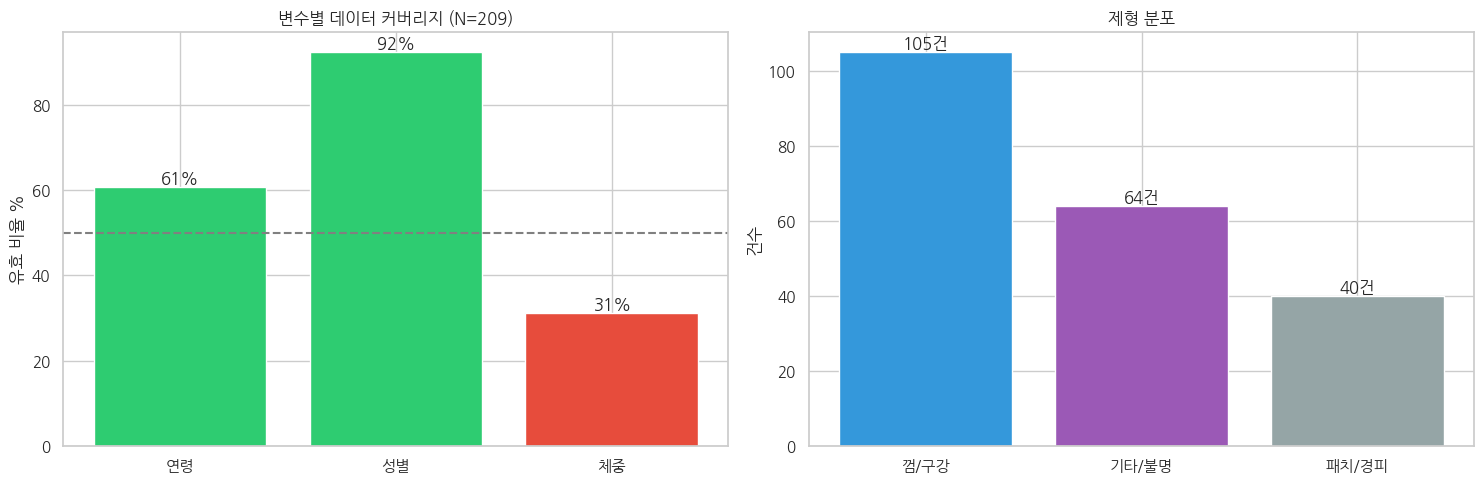

In [4]:
# 데이터 커버리지 + 제형 분포
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
cov = {'연령': nic['age_num'].notna().mean()*100,
       '성별': (nic['sex']!='Unknown').mean()*100,
       '체중': nic['weight_num'].notna().mean()*100}
ax[0].bar(cov.keys(), cov.values(),
          color=['#2ecc71' if v>=60 else '#f39c12' if v>=40 else '#e74c3c' for v in cov.values()])
ax[0].axhline(50, color='gray', ls='--', label='50% 기준선')
ax[0].set_title(f'변수별 데이터 커버리지 (N={len(nic)})', fontweight='bold'); ax[0].set_ylabel('유효 비율 %')
for i,(k,v) in enumerate(cov.items()): ax[0].text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontweight='bold')

fc = nic['form'].value_counts()
ax[1].bar(fc.index, fc.values, color=['#3498db','#9b59b6','#95a5a6'])
ax[1].set_title('제형 분포', fontweight='bold'); ax[1].set_ylabel('건수')
for i,v in enumerate(fc.values): ax[1].text(i, v, f'{v}건', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

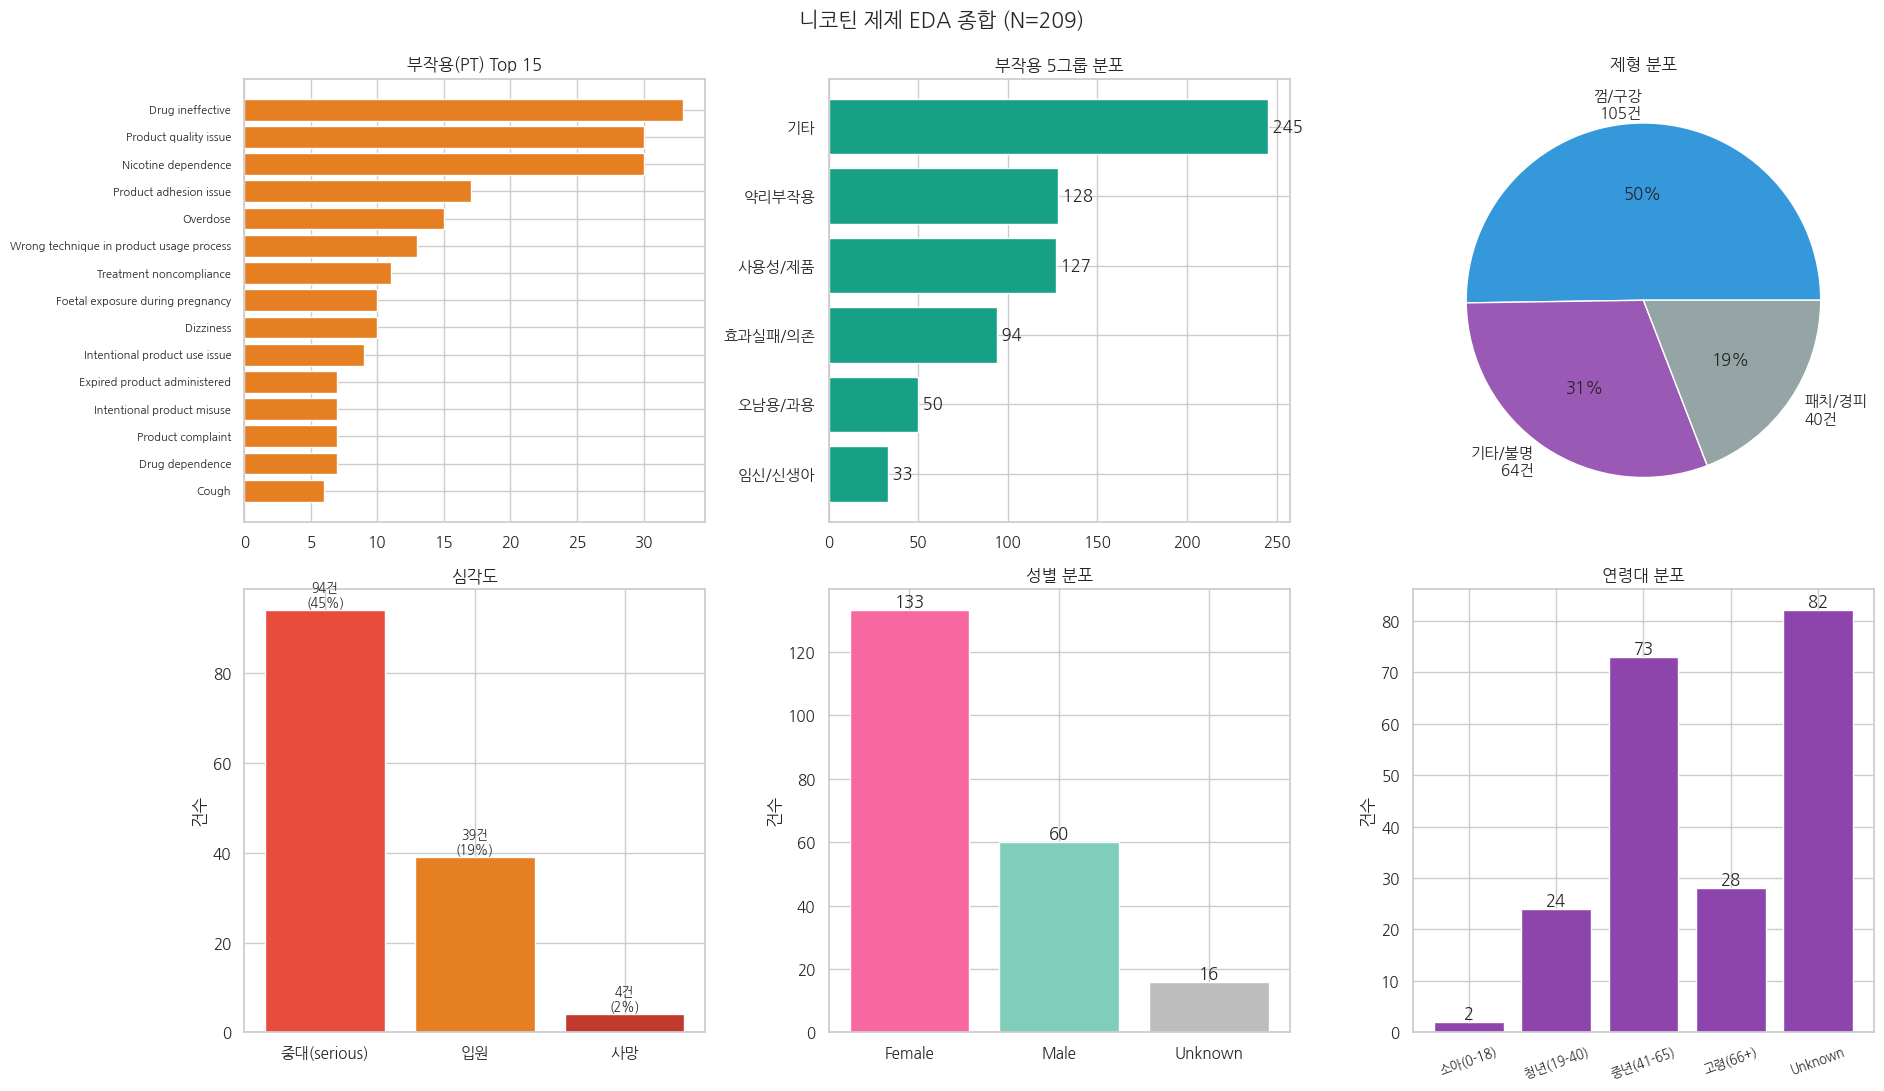

In [5]:
# 니코틴 제제 EDA 종합 (부작용/그룹분포/제형/심각도/성별/연령대)
fig, axes = plt.subplots(2, 3, figsize=(19, 11))

top = reac['reaction_list'].value_counts().head(15)
axes[0,0].barh(top.index[::-1], top.values[::-1], color='#e67e22')
axes[0,0].set_title('부작용(PT) Top 15', fontweight='bold'); axes[0,0].tick_params(axis='y', labelsize=8)

g = reac['grp'].value_counts()
axes[0,1].barh(g.index[::-1], g.values[::-1], color='#16a085')
axes[0,1].set_title('부작용 5그룹 분포', fontweight='bold')
for i,v in enumerate(g.values[::-1]): axes[0,1].text(v, i, f' {v}', va='center')

fc = nic['form'].value_counts()
axes[0,2].pie(fc.values, labels=[f'{i}\n{v}건' for i,v in fc.items()],
              autopct='%1.0f%%', colors=['#3498db','#9b59b6','#95a5a6'])
axes[0,2].set_title('제형 분포', fontweight='bold')

sev = {'중대(serious)': nic['serious_b'].sum(), '입원': nic['is_hospitalized_b'].sum(),
       '사망': nic['is_fatal_b'].sum()}
axes[1,0].bar(sev.keys(), sev.values(), color=['#e74c3c','#e67e22','#c0392b'])
axes[1,0].set_title('심각도', fontweight='bold'); axes[1,0].set_ylabel('건수')
for i,v in enumerate(sev.values()):
    axes[1,0].text(i, v, f'{v}건\n({v/len(nic)*100:.0f}%)', ha='center', va='bottom', fontsize=9)

sx = nic['sex'].value_counts()
axes[1,1].bar(sx.index, sx.values, color=['#f768a1','#7fcdbb','#bdbdbd'])
axes[1,1].set_title('성별 분포', fontweight='bold'); axes[1,1].set_ylabel('건수')
for i,v in enumerate(sx.values): axes[1,1].text(i, v, f'{v}', ha='center', va='bottom')

ao = ['소아(0-18)','청년(19-40)','중년(41-65)','고령(66+)','Unknown']
ac = nic['age_band'].value_counts().reindex(ao).fillna(0)
axes[1,2].bar(range(len(ac)), ac.values, color='#8e44ad')
axes[1,2].set_xticks(range(len(ac))); axes[1,2].set_xticklabels(ac.index, rotation=20, fontsize=9)
axes[1,2].set_title('연령대 분포', fontweight='bold'); axes[1,2].set_ylabel('건수')
for i,v in enumerate(ac.values): axes[1,2].text(i, v, f'{int(v)}', ha='center', va='bottom')

plt.suptitle(f'니코틴 제제 EDA 종합 (N={len(nic)})', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout(); plt.show()

In [6]:
# 껌 vs 패치 부작용 그룹 구성비 + Fisher 정확검정
two = reac[reac['form'].isin(['껌/구강','패치/경피'])]
grp_order = ['약리부작용','사용성/제품','효과실패/의존','오남용/과용','임신/신생아','기타']

ct = pd.crosstab(two['form'], two['grp']).reindex(index=['껌/구강','패치/경피'], columns=grp_order)
pct = ct.div(ct.sum(axis=1), axis=0) * 100

case_grp = reac.groupby(['report_id','form'])['grp'].apply(set).reset_index()
print('=== 그룹별 껌 vs 패치 Fisher 정확검정 ===')
for g in grp_order:
    if g == '기타': continue
    tab = pd.crosstab(case_grp['form'], case_grp['grp'].apply(lambda s: g in s)).reindex(['껌/구강','패치/경피'])
    if tab.shape == (2,2):
        odds, p = stats.fisher_exact(tab)
        print(f'  {g}: Fisher p={p:.3f} {"유의" if p<0.05 else ""}')

=== 그룹별 껌 vs 패치 Fisher 정확검정 ===
  약리부작용: Fisher p=0.565 
  사용성/제품: Fisher p=0.000 유의
  효과실패/의존: Fisher p=0.129 
  오남용/과용: Fisher p=0.364 
  임신/신생아: Fisher p=0.011 유의


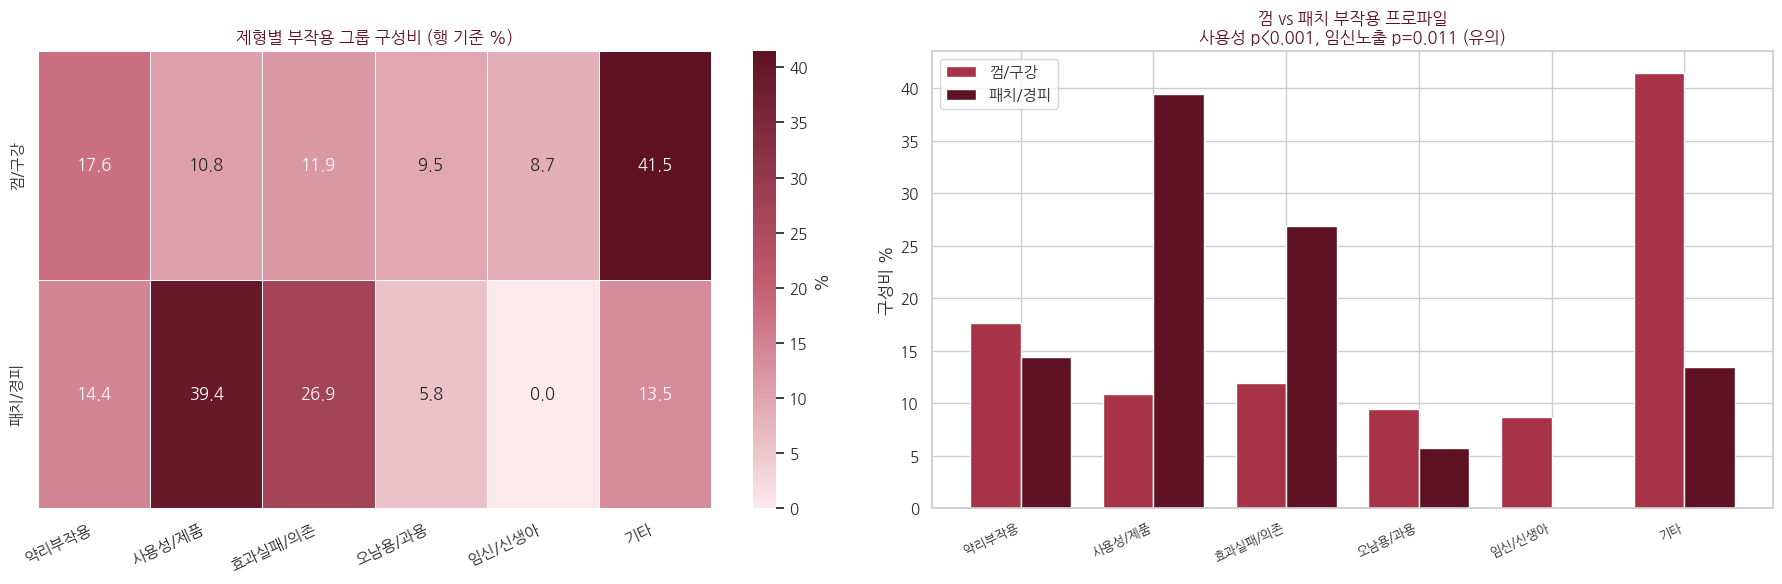

In [7]:
# 제형별 부작용 그룹 구성비 히트맵 + 그룹막대
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pct, annot=True, fmt='.1f', cmap=burg_cmap, ax=ax[0],
            cbar_kws={'label':'%'}, linewidths=.5, linecolor='white')
ax[0].set_title('제형별 부작용 그룹 구성비 (행 기준 %)', fontweight='bold', color='#5e1223')
ax[0].set_xlabel(''); ax[0].set_ylabel('')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=25, ha='right')

x = np.arange(len(grp_order)); w = 0.38
ax[1].bar(x-w/2, pct.loc['껌/구강'], w, label='껌/구강', color='#a83248')
ax[1].bar(x+w/2, pct.loc['패치/경피'], w, label='패치/경피', color='#5e1223')
ax[1].set_xticks(x); ax[1].set_xticklabels(grp_order, rotation=25, ha='right', fontsize=9); ax[1].legend()
ax[1].set_title('껌 vs 패치 부작용 프로파일\n사용성 p<0.001, 임신노출 p=0.011 (유의)',
                fontweight='bold', color='#5e1223')
ax[1].set_ylabel('구성비 %')

plt.tight_layout(); plt.show()

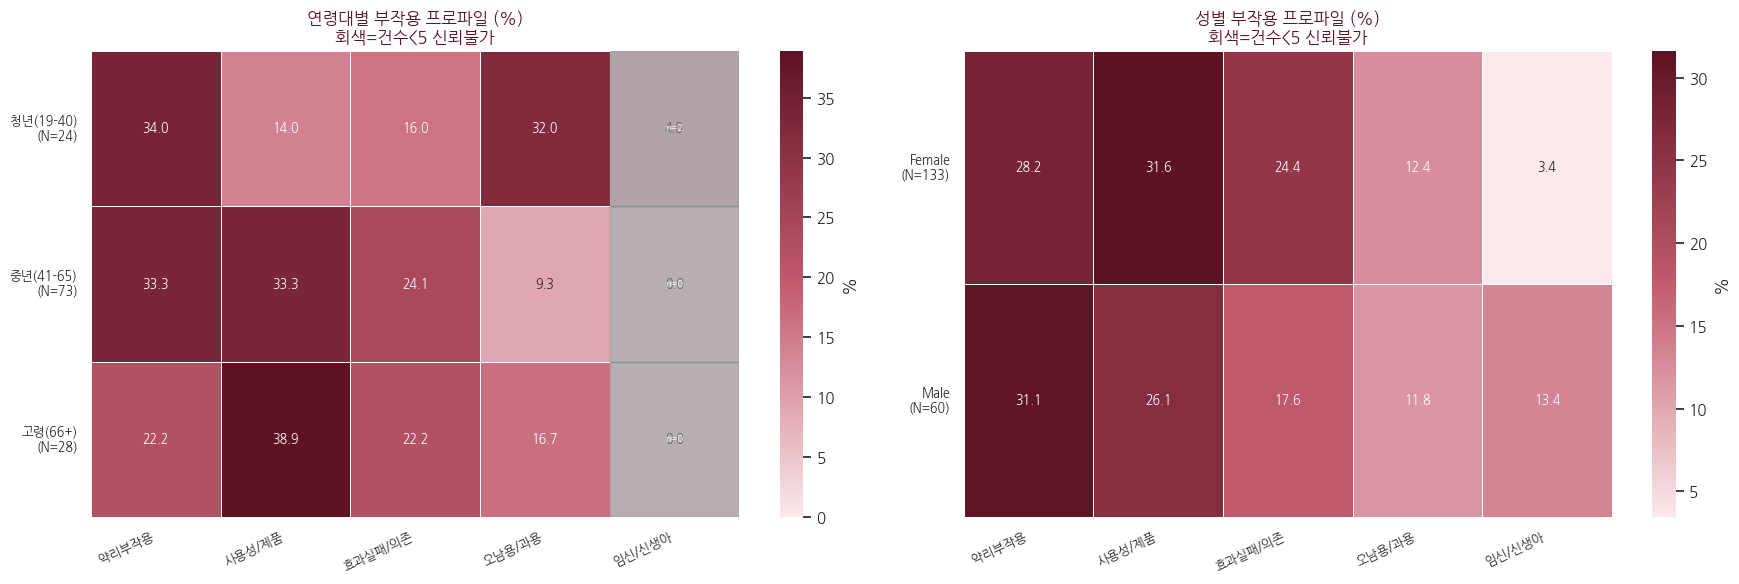

In [8]:
# 연령대별/성별 부작용 프로파일 층화 히트맵 (건수<5는 회색 처리)
MIN = 5
grp_order = ['약리부작용','사용성/제품','효과실패/의존','오남용/과용','임신/신생아']

def stratified_heatmap(ax, idx_col, order, title):
    """층화 히트맵 + 저건수 셀 회색 처리 + 행 라벨에 N 병기"""
    r = reac[reac[idx_col].isin(order)]
    ct = pd.crosstab(r[idx_col], r['grp']).reindex(index=order, columns=grp_order).fillna(0)
    pct = ct.div(ct.sum(axis=1), axis=0) * 100

    cg = reac.groupby(['report_id', idx_col])['grp'].apply(set).reset_index()
    cnt = pd.DataFrame(
        {g: [cg[cg[idx_col]==o]['grp'].apply(lambda s: g in s).sum() for o in order] for g in grp_order},
        index=order)
    Ns = [nic[nic[idx_col]==o]['report_id'].nunique() for o in order]
    ylab = [f'{o}\n(N={N})' for o, N in zip(order, Ns)]

    sns.heatmap(pct, annot=True, fmt='.1f', cmap=burg_cmap, ax=ax,
                cbar_kws={'label':'%'}, linewidths=.5, linecolor='white', annot_kws={'fontsize':9})
    for i in range(pct.shape[0]):
        for j in range(pct.shape[1]):
            if cnt.values[i,j] < MIN:
                ax.add_patch(plt.Rectangle((j,i), 1, 1, fill=True, color='#888', alpha=0.6, zorder=3))
                ax.text(j+0.5, i+0.5, f'n={int(cnt.values[i,j])}', ha='center', va='center',
                        fontsize=7, color='white', zorder=4)
    ax.set_title(title, fontweight='bold', color='#5e1223')
    ax.set_yticklabels(ylab, rotation=0, fontsize=9)
    ax.set_xticklabels(grp_order, rotation=25, ha='right', fontsize=9)
    ax.set_xlabel(''); ax.set_ylabel('')

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
stratified_heatmap(ax[0], 'age_band', ['청년(19-40)','중년(41-65)','고령(66+)'],
                   '연령대별 부작용 프로파일 (%)\n회색=건수<5 신뢰불가')
stratified_heatmap(ax[1], 'sex', ['Female','Male'],
                   '성별 부작용 프로파일 (%)\n회색=건수<5 신뢰불가')
plt.tight_layout(); plt.show()

In [9]:
# 임신/신생아 관련 케이스 상세
preg = reac[reac['grp']=='임신/신생아']
print('임신/신생아 관련 케이스:', preg['report_id'].nunique(), '건')
print('제형 분포:', preg.groupby('report_id')['form'].first().value_counts().to_dict())
print(preg['reaction_list'].value_counts())

임신/신생아 관련 케이스: 15 건
제형 분포: {'껌/구강': 14, '기타/불명': 1}
reaction_list
Foetal exposure during pregnancy          10
Drug withdrawal syndrome neonatal          6
Maternal exposure during pregnancy         2
Neonatal respiratory distress syndrome     2
Exposure via breast milk                   2
Exposure during breast feeding             1
Agitation neonatal                         1
Hyperbilirubinaemia neonatal               1
Exposure during pregnancy                  1
Neonatal hepatomegaly                      1
Tremor neonatal                            1
Jaundice neonatal                          1
Foetal hypokinesia                         1
Neutropenia neonatal                       1
Foetal disorder                            1
Meningitis neonatal                        1
Name: count, dtype: int64


In [10]:
# 효과실패 케이스의 사용성 문제 동반율 (Fisher)
case_grp = reac.groupby('report_id')['grp'].apply(set)
fail = case_grp.apply(lambda s: '효과실패/의존' in s)
use  = case_grp.apply(lambda s: '사용성/제품' in s)

odds, p = stats.fisher_exact(pd.crosstab(fail, use))
print(f'효과실패 케이스의 사용성 동반율: {(fail&use).sum()/fail.sum()*100:.0f}%')
print(f'효과실패 없는 케이스의 사용성율: {(~fail&use).sum()/(~fail).sum()*100:.0f}%')
print(f'Fisher p={p:.3f}')

효과실패 케이스의 사용성 동반율: 56%
효과실패 없는 케이스의 사용성율: 37%
Fisher p=0.009


In [11]:
# 오남용/과용 케이스 상세
mis = reac[reac['grp']=='오남용/과용']
print(mis['reaction_list'].value_counts().head(10))
print('제형:', mis.groupby('report_id')['form'].first().value_counts().to_dict())

reaction_list
Overdose                          15
Intentional product use issue      9
Intentional product misuse         7
Drug abuse                         4
Underdose                          4
Accidental exposure to product     2
Alcohol abuse                      2
Drug abuser                        2
Tobacco abuse                      1
Accidental overdose                1
Name: count, dtype: int64
제형: {'껌/구강': 25, '기타/불명': 9, '패치/경피': 6}


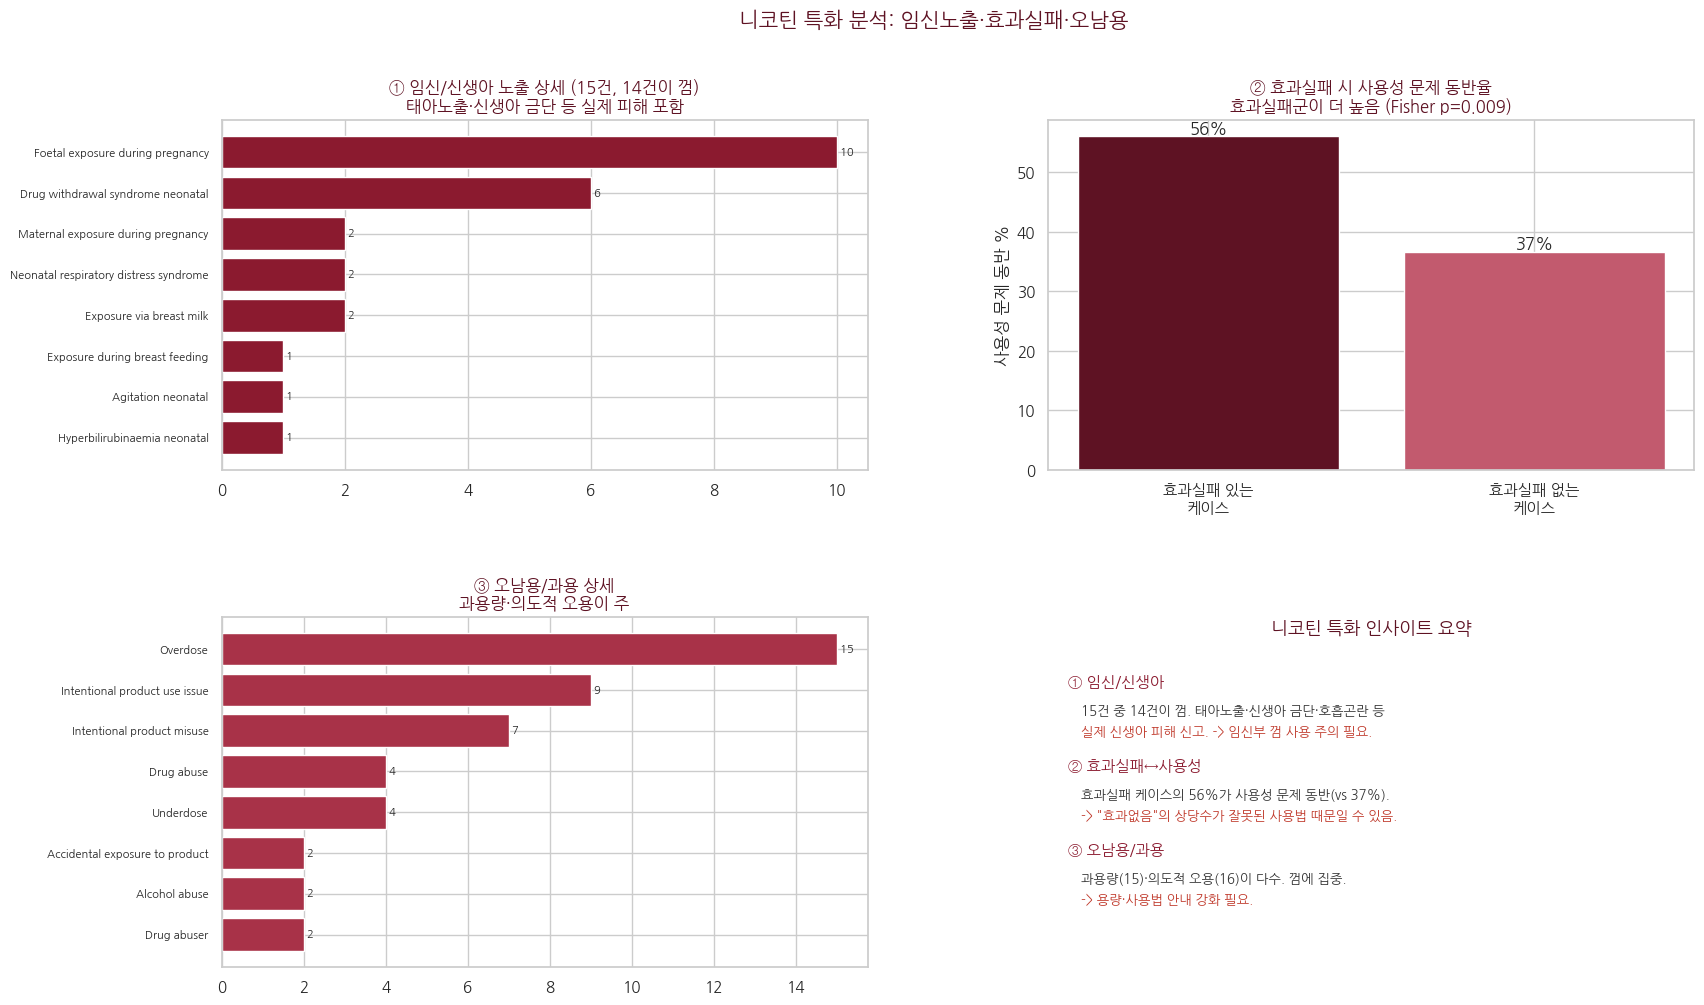

In [12]:
# 니코틴 특화 인사이트 종합 (임신/신생아, 효과실패-사용성, 오남용, 텍스트 요약)
fig = plt.figure(figsize=(19, 11))
gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.28)

axA = fig.add_subplot(gs[0, 0])
preg_top = reac[reac['grp']=='임신/신생아']['reaction_list'].value_counts().head(8)
axA.barh(preg_top.index[::-1], preg_top.values[::-1], color='#8b1a2f')
axA.set_title('① 임신/신생아 노출 상세 (15건, 14건이 껌)\n태아노출·신생아 금단 등 실제 피해 포함',
              fontsize=12, fontweight='bold', color='#5e1223')
axA.tick_params(axis='y', labelsize=8)
for i, v in enumerate(preg_top.values[::-1]):
    axA.text(v, i, f' {v}', va='center', fontsize=8)

axB = fig.add_subplot(gs[0, 1])
data = [(fail & use).sum()/fail.sum()*100, (~fail & use).sum()/(~fail).sum()*100]
odds, p = stats.fisher_exact(pd.crosstab(fail, use))
axB.bar(['효과실패 있는\n케이스', '효과실패 없는\n케이스'], data, color=['#5e1223', '#c25a6e'])
axB.set_title(f'② 효과실패 시 사용성 문제 동반율\n효과실패군이 더 높음 (Fisher p={p:.3f})',
              fontsize=12, fontweight='bold', color='#5e1223')
axB.set_ylabel('사용성 문제 동반 %')
for i, v in enumerate(data):
    axB.text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontweight='bold')

axC = fig.add_subplot(gs[1, 0])
mis_top = reac[reac['grp']=='오남용/과용']['reaction_list'].value_counts().head(8)
axC.barh(mis_top.index[::-1], mis_top.values[::-1], color='#a83248')
axC.set_title('③ 오남용/과용 상세\n과용량·의도적 오용이 주', fontsize=12, fontweight='bold', color='#5e1223')
axC.tick_params(axis='y', labelsize=8)
for i, v in enumerate(mis_top.values[::-1]):
    axC.text(v, i, f' {v}', va='center', fontsize=8)

axD = fig.add_subplot(gs[1, 1]); axD.axis('off')
axD.text(0.5, 0.95, '니코틴 특화 인사이트 요약', ha='center',
         fontsize=13, fontweight='bold', color='#5e1223')
txt = [('① 임신/신생아', '15건 중 14건이 껌. 태아노출·신생아 금단·호흡곤란 등', '실제 신생아 피해 신고. -> 임신부 껌 사용 주의 필요.'),
       ('② 효과실패↔사용성', '효과실패 케이스의 56%가 사용성 문제 동반(vs 37%).', '-> "효과없음"의 상당수가 잘못된 사용법 때문일 수 있음.'),
       ('③ 오남용/과용', '과용량(15)·의도적 오용(16)이 다수. 껌에 집중.', '-> 용량·사용법 안내 강화 필요.')]
yy = 0.80
for t, a, b in txt:
    axD.text(0.03, yy, t, fontsize=11, fontweight='bold', color='#8b1a2f'); yy -= 0.08
    axD.text(0.05, yy, a, fontsize=9.5, color='#333'); yy -= 0.06
    axD.text(0.05, yy, b, fontsize=9.5, color='#c0392b'); yy -= 0.10

plt.suptitle('니코틴 특화 분석: 임신노출·효과실패·오남용',
             fontsize=15, fontweight='bold', y=0.98, color='#5e1223')
plt.show()

In [13]:
# 요인(제형/성별/연령대) x 부작용그룹 검정 + FDR 보정
def test_factor(idx_col, order, label):
    """요인 x 각 부작용그룹 검정 + FDR 보정"""
    cg = reac.groupby(['report_id', idx_col])['grp'].apply(set).reset_index()
    cg = cg[cg[idx_col].isin(order)]
    pvals = []
    for g in grp_order:
        flag = cg['grp'].apply(lambda s: g in s)
        tab = pd.crosstab(cg[idx_col], flag)
        if tab.shape[1] < 2:
            pvals.append(1.0); continue
        if tab.shape == (2,2):
            _, p = stats.fisher_exact(tab)
        else:
            _, p, _, _ = stats.chi2_contingency(tab)
        pvals.append(p)
    p_fdr = multipletests(pvals, method='fdr_bh')[1]
    print(f'=== {label} x 부작용 ===')
    for g, p, pf in zip(grp_order, pvals, p_fdr):
        print(f'  {g:10s}: p={p:.3f} -> FDR={pf:.3f} {"유의" if pf<0.05 else ""}')

test_factor('form', ['껌/구강','패치/경피'], '제형')
test_factor('sex',  ['Female','Male'], '성별')
test_factor('age_band', ['청년(19-40)','중년(41-65)','고령(66+)'], '연령대')

=== 제형 x 부작용 ===
  약리부작용     : p=0.565 -> FDR=0.565 
  사용성/제품    : p=0.000 -> FDR=0.000 유의
  효과실패/의존   : p=0.129 -> FDR=0.214 
  오남용/과용    : p=0.364 -> FDR=0.456 
  임신/신생아    : p=0.011 -> FDR=0.028 유의
=== 성별 x 부작용 ===
  약리부작용     : p=0.874 -> FDR=0.874 
  사용성/제품    : p=0.533 -> FDR=0.874 
  효과실패/의존   : p=0.264 -> FDR=0.661 
  오남용/과용    : p=0.702 -> FDR=0.874 
  임신/신생아    : p=0.099 -> FDR=0.497 
=== 연령대 x 부작용 ===
  약리부작용     : p=0.741 -> FDR=0.741 
  사용성/제품    : p=0.073 -> FDR=0.122 
  효과실패/의존   : p=0.486 -> FDR=0.608 
  오남용/과용    : p=0.016 -> FDR=0.039 유의
  임신/신생아    : p=0.014 -> FDR=0.039 유의
